In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [85]:
df = pd.read_csv("/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.shape

(7043, 21)

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


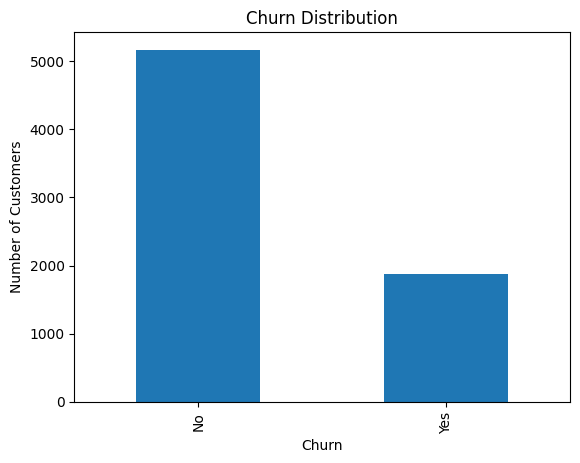

In [19]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

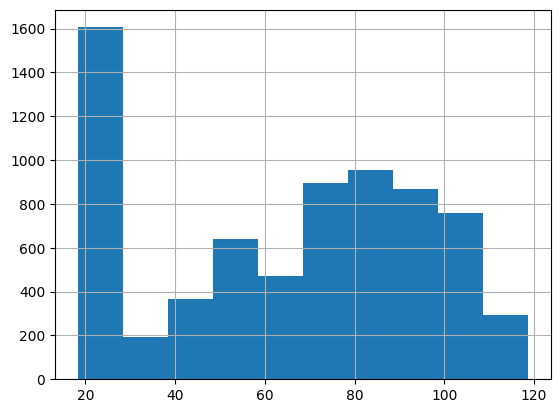

In [20]:
df["MonthlyCharges"].hist()
plt.show()

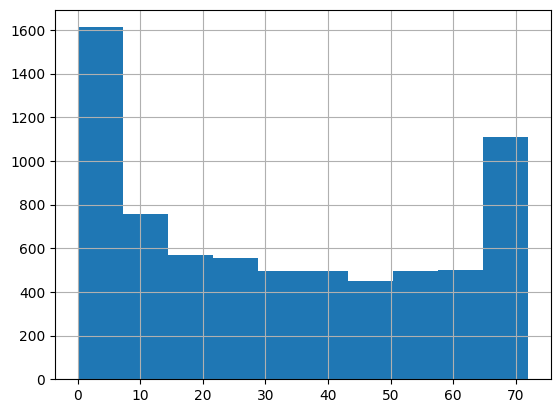

In [21]:
df["tenure"].hist()
plt.show()

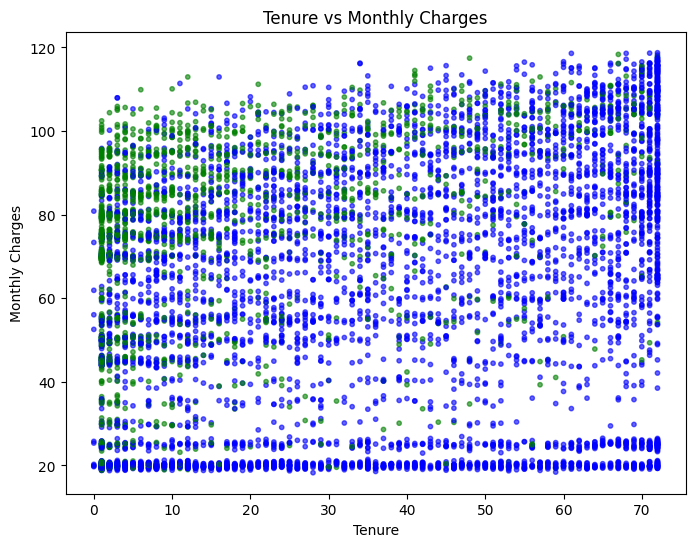

In [33]:
import matplotlib.pyplot as plt

colors = df["Churn"].map({"Yes":"green","No":"blue"})

plt.figure(figsize=(8,6))

plt.scatter(df["tenure"], df["MonthlyCharges"], c=colors, s=10, alpha=0.6)

plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.title("Tenure vs Monthly Charges")

plt.show()

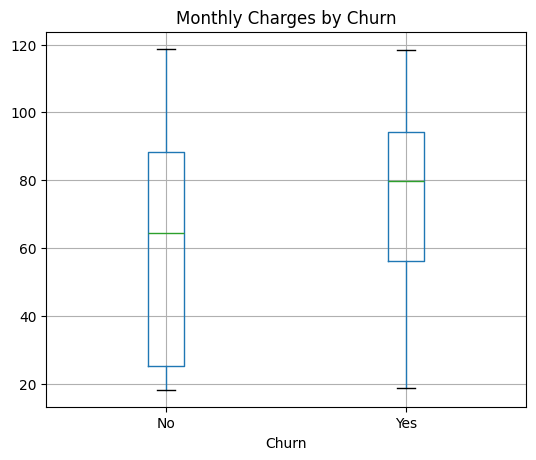

In [34]:
df.boxplot(column="MonthlyCharges", by="Churn", figsize=(6,5))
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.show()

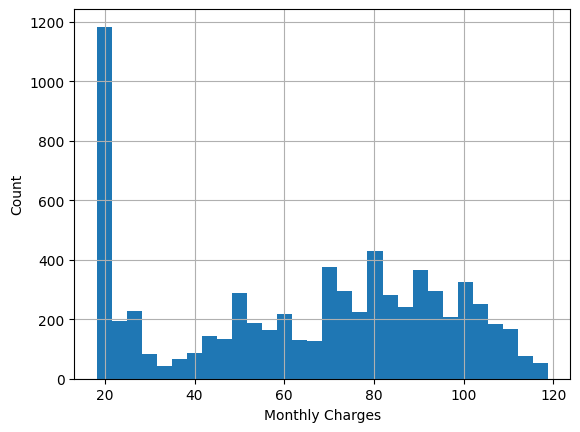

In [35]:
df["MonthlyCharges"].hist(bins=30)
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()

In [36]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [105]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric, coercing errors and filling NaNs with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [100]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

# Fit the model using scaled training data
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [102]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409


Confusion Matrix:
[[934 102]
 [151 222]]


In [93]:
# Convert Target to Numbers
print("Churn value_counts BEFORE conversion:")
print(df["Churn"].value_counts())

df["Churn"] = (df["Churn"].astype(str).str.strip() == "Yes").astype(int)

# Verify Churn distribution after conversion
print("\nChurn distribution AFTER conversion:")
print(df["Churn"].value_counts())

Churn value_counts BEFORE conversion:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn distribution AFTER conversion:
Churn
0    7043
Name: count, dtype: int64


In [88]:
# This cell is intentionally left empty as get_dummies will be applied to X after separation

In [89]:
# Separate features (X) and target (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Apply one-hot encoding to features (X) only
X = pd.get_dummies(X, drop_first=True)

In [99]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42
                                                    )

# Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [92]:
# Check for NaN values in y_train
print("Number of NaN values in y_train:", y_train.isnull().sum())

Number of NaN values in y_train: 0


In [106]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [107]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [108]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(X_train, y_train)

KNeighborsClassifier()

In [109]:
prediction = model.predict(X_test)

In [119]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, prediction)
print(f"Accuracy for Prdiction: {accuracy:.2%}")

Accuracy for Prdiction: 77.71%


### Accuracy of Logistic Regression Model

In [115]:
from sklearn.metrics import accuracy_score

# The y_pred for Logistic Regression was already calculated in cell dpzO5FlETso_
accuracy_lr = accuracy_score(y_test, y_pred)
print(f"Accuracy for Logistic Regression: {accuracy_lr:.2%}")

Accuracy for Logistic Regression: 82.04%


### Accuracy of Decision Tree Classifier

In [116]:
# Re-train Decision Tree Model (trained on unscaled data)
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Make predictions with the Decision Tree model on unscaled X_test
dt_prediction = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, dt_prediction)
print(f"Accuracy for Decision Tree Classifier: {accuracy_dt:.2%}")

Accuracy for Decision Tree Classifier: 71.40%


### Accuracy of Random Forest Classifier

In [117]:
# Re-train Random Forest Model (trained on unscaled data)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Make predictions with the Random Forest model on unscaled X_test
rf_prediction = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, rf_prediction)
print(f"Accuracy for Random Forest Classifier: {accuracy_rf:.2%}")

Accuracy for Random Forest Classifier: 79.13%


In [141]:
print(f"Logistic Regression: {accuracy_lr:.2%}")
print(f"Random Forest: {accuracy_rf:.2%}")

Logistic Regression: 82.04%
Random Forest: 79.13%


In [138]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_ * 100  # Convert to percentage
})

importance = importance.sort_values(by="Importance", ascending=False)

# Format the Importance column as a string with percentage sign for display
importance['Importance'] = importance['Importance'].map('{:.2f}%'.format)

print(importance.head(10))

                           Feature Importance
3                     TotalCharges     19.95%
2                   MonthlyCharges     16.86%
1                           tenure     16.66%
10     InternetService_Fiber optic      3.75%
25               Contract_Two year      3.45%
28  PaymentMethod_Electronic check      3.41%
4                      gender_Male      2.78%
26            PaperlessBilling_Yes      2.59%
13              OnlineSecurity_Yes      2.47%
24               Contract_One year      2.38%


In [137]:
print(f"Number of features (rows) in the importance table: {len(importance)}")

Number of features (rows) in the importance table: 30


In [147]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0] # Use lr_model to get coefficients
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print(feature_importance.head(10))

                        Feature  Coefficient
1                        tenure    -1.347355
3                  TotalCharges     0.649427
2                MonthlyCharges    -0.628014
10  InternetService_Fiber optic     0.619853
25            Contract_Two year    -0.613702
24            Contract_One year    -0.268336
23          StreamingMovies_Yes     0.228714
21              StreamingTV_Yes     0.179380
9             MultipleLines_Yes     0.168199
26         PaperlessBilling_Yes     0.163829


In [148]:
import joblib
from sklearn.linear_model import LogisticRegression

# Re-instantiate and fit the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Save the Logistic Regression model
joblib.dump(lr_model, "customer_churn_model.pkl")

['customer_churn_model.pkl']